# Lipi
## Odia Handwritten OCR Project

Lipi is a machine learning project focused on handwritten Odia character recognition.

The goal of this project is to:
- build a structured Odia OCR pipeline
- create and manage custom datasets
- train deep learning models for character recognition
- support regional language AI research

---

## Project Objectives

- Collect handwritten Odia character dataset
- Build preprocessing pipeline
- Train CNN-based OCR models
- Evaluate recognition accuracy
- Build deployable OCR system

# Project Structure

```text
lipi/
│
├── data/
│   ├── raw/
│   ├── processed/
│   ├── samples/
│   └── mini_dataset/
│
├── notebooks/
│   ├── 01_dataset_exploration.ipynb
│   ├── 02_preprocessing.ipynb
│   ├── 03_first_cnn.ipynb
│   ├── 04_full_training.ipynb
│   └── 05_evaluation.ipynb
│
├── src/
│   ├── config/
│   ├── preprocessing/
│   ├── training/
│   ├── evaluation/
│   └── deployment/
│
├── models/
├── outputs/
├── requirements.txt
└── README.md

# Step 1: Install Required Libraries

We install the required Python libraries for:
- image processing
- visualization
- machine learning
- dataset management

# Step 2: Import Required Libraries

We import:
- os for file handling
- pandas for dataset indexing
- matplotlib for visualization
- PIL for image processing

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

# Step 3: Mount Google Drive

The handwritten dataset is stored in Google Drive.

Google Drive is used instead of GitHub because:
- image datasets are large
- GitHub is optimized for code
- datasets should remain separate from source code

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 4: Define Dataset Path

Now we tell Python where our handwritten dataset is stored inside Google Drive.

Our dataset structure looks like this:

```
mini_dataset/
├── CONS_KA/
├── CONS_KHA/
├── CONS_GA/
├── VOW_A/
└── ...
```


Each folder represents one character class.

We will load all images from these folders for training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset path inside Google Drive

DATASET_DIR = "/content/drive/MyDrive/lipi/mini_dataset"

print("Dataset Path:", DATASET_DIR)

Dataset Path: /content/drive/MyDrive/lipi/mini_dataset


# Step 5: Verify Dataset Structure

Before training a model, we must verify that:
- folders exist
- images exist
- dataset is readable

This helps catch path mistakes early.

Machine learning debugging is mostly:
"the file path is wrong again."

In [ ]:
import os

# List all folders/classes

classes = os.listdir(DATASET_DIR)

print("Total Classes:", len(classes))
print(classes[:10])

Total Classes: 55
['CONS_BA', 'CONS_BHA', 'CONS_CA', 'CONS_CHA', 'CONS_DDA', 'CONS_DA', 'CONS_DDHA', 'CONS_GA', 'CONS_DHA', 'CONS_GHA']


# Step 6: Count Images Per Class

Now we check:
- how many images each character contains
- whether any folders are empty
- whether dataset distribution is balanced

Balanced datasets usually train better.

In [ ]:
for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(
        DATASET_DIR,
        folder
    )

    # Skip non-folder files
    if not os.path.isdir(folder_path):
        continue

    image_count = len(os.listdir(folder_path))

    print(f"{folder} → {image_count} images")

CONS_BA → 30 images
CONS_BHA → 16 images
CONS_CA → 39 images
CONS_CHA → 29 images
CONS_DDA → 28 images
CONS_DA → 29 images
CONS_DDHA → 28 images
CONS_GA → 30 images
CONS_DHA → 28 images
CONS_GHA → 29 images
CONS_HA → 26 images
CONS_JA → 27 images
CONS_JHA → 27 images
CONS_KA → 45 images
CONS_KHA → 37 images
CONS_LA → 33 images
CONS_LLA → 28 images
CONS_MA → 26 images
CONS_NGA → 30 images
CONS_NNA → 32 images
CONS_NYA → 28 images
CONS_PA → 28 images
CONS_PHA → 34 images
CONS_NA → 26 images
CONS_SA → 33 images
CONS_RA → 29 images
CONS_SSHA → 27 images
CONS_SHA → 29 images
CONS_TA → 28 images
CONS_THA → 25 images
CONS_TTHA → 33 images
CONS_TTA → 34 images
CONS_YA → 29 images
CONS_YYA → 26 images
DIGIT_0 → 8 images
DIGIT_2 → 8 images
DIGIT_1 → 7 images
DIGIT_3 → 6 images
DIGIT_5 → 8 images
DIGIT_8 → 2 images
DIGIT_6 → 7 images
DIGIT_4 → 7 images
DIGIT_7 → 8 images
DIGIT_9 → 6 images
VOW_AA → 28 images
VOW_A → 34 images
VOW_AU → 30 images
VOW_AI → 30 images
VOW_E → 28 images
VOW_I → 30 imag

# Step 7: Filter Valid Classes

Some folders may contain:
- too few images
- accidental files
- incomplete data

We keep only classes with enough images.

This improves training stability.

In [ ]:
MIN_IMAGES = 25

valid_classes = []

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(
        DATASET_DIR,
        folder
    )

    if not os.path.isdir(folder_path):
        continue

    image_count = len(os.listdir(folder_path))

    if image_count >= MIN_IMAGES:

        valid_classes.append(folder)

        print(f"{folder} → {image_count} images")

CONS_BA → 30 images
CONS_CA → 39 images
CONS_CHA → 29 images
CONS_DDA → 28 images
CONS_DA → 29 images
CONS_DDHA → 28 images
CONS_GA → 30 images
CONS_DHA → 28 images
CONS_GHA → 29 images
CONS_HA → 26 images
CONS_JA → 27 images
CONS_JHA → 27 images
CONS_KA → 45 images
CONS_KHA → 37 images
CONS_LA → 33 images
CONS_LLA → 28 images
CONS_MA → 26 images
CONS_NGA → 30 images
CONS_NNA → 32 images
CONS_NYA → 28 images
CONS_PA → 28 images
CONS_PHA → 34 images
CONS_NA → 26 images
CONS_SA → 33 images
CONS_RA → 29 images
CONS_SSHA → 27 images
CONS_SHA → 29 images
CONS_TA → 28 images
CONS_THA → 25 images
CONS_TTHA → 33 images
CONS_TTA → 34 images
CONS_YA → 29 images
CONS_YYA → 26 images
VOW_AA → 28 images
VOW_A → 34 images
VOW_AU → 30 images
VOW_AI → 30 images
VOW_E → 28 images
VOW_I → 30 images
VOW_II → 32 images
VOW_O → 29 images
VOW_U → 30 images


# Step 8: Sort Class Names

Sorting ensures:
- consistent label ordering
- reproducible training
- easier debugging

Without sorting:
the same class may get different labels later.
Tiny chaos. Huge consequences.

In [ ]:
valid_classes.sort()

print(valid_classes)

['CONS_BA', 'CONS_CA', 'CONS_CHA', 'CONS_DA', 'CONS_DDA', 'CONS_DDHA', 'CONS_DHA', 'CONS_GA', 'CONS_GHA', 'CONS_HA', 'CONS_JA', 'CONS_JHA', 'CONS_KA', 'CONS_KHA', 'CONS_LA', 'CONS_LLA', 'CONS_MA', 'CONS_NA', 'CONS_NGA', 'CONS_NNA', 'CONS_NYA', 'CONS_PA', 'CONS_PHA', 'CONS_RA', 'CONS_SA', 'CONS_SHA', 'CONS_SSHA', 'CONS_TA', 'CONS_THA', 'CONS_TTA', 'CONS_TTHA', 'CONS_YA', 'CONS_YYA', 'VOW_A', 'VOW_AA', 'VOW_AI', 'VOW_AU', 'VOW_E', 'VOW_I', 'VOW_II', 'VOW_O', 'VOW_U']


# Step 9: Create Label Map

Machine learning models do NOT understand:
- "CONS_KA"
- "VOW_A"

They only understand numbers.

So we convert:

CONS_KA → 0
CONS_KHA → 1
CONS_GA → 2

This process is called:
Label Encoding

In [ ]:
label_map = {}

for idx, class_name in enumerate(valid_classes):

    label_map[class_name] = idx

print(label_map)

{'CONS_BA': 0, 'CONS_CA': 1, 'CONS_CHA': 2, 'CONS_DA': 3, 'CONS_DDA': 4, 'CONS_DDHA': 5, 'CONS_DHA': 6, 'CONS_GA': 7, 'CONS_GHA': 8, 'CONS_HA': 9, 'CONS_JA': 10, 'CONS_JHA': 11, 'CONS_KA': 12, 'CONS_KHA': 13, 'CONS_LA': 14, 'CONS_LLA': 15, 'CONS_MA': 16, 'CONS_NA': 17, 'CONS_NGA': 18, 'CONS_NNA': 19, 'CONS_NYA': 20, 'CONS_PA': 21, 'CONS_PHA': 22, 'CONS_RA': 23, 'CONS_SA': 24, 'CONS_SHA': 25, 'CONS_SSHA': 26, 'CONS_TA': 27, 'CONS_THA': 28, 'CONS_TTA': 29, 'CONS_TTHA': 30, 'CONS_YA': 31, 'CONS_YYA': 32, 'VOW_A': 33, 'VOW_AA': 34, 'VOW_AI': 35, 'VOW_AU': 36, 'VOW_E': 37, 'VOW_I': 38, 'VOW_II': 39, 'VOW_O': 40, 'VOW_U': 41}


# Step 10: Load Dataset Images

Now we:
- read every image
- convert to grayscale
- resize to fixed dimensions
- normalize pixel values

Why normalization?

Images normally use:
0 → 255

Neural networks train better with:
0 → 1

In [ ]:
images = []
labels = []

IMG_SIZE = 64

loaded_count = 0
failed_count = 0

for class_name in valid_classes:

    class_path = os.path.join(
        DATASET_DIR,
        class_name
    )

    label = label_map[class_name]

    # Read all image files
    for image_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            image_name
        )

        # Read image
        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Skip broken images
        if img is None:
            failed_count += 1
            print("Failed:", img_path)
            continue

        # Resize image
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        # Normalize pixel values
        img = img / 255.0

        # Save image + label
        images.append(img)
        labels.append(label)

        loaded_count += 1

print("Images Loaded :", loaded_count)
print("Images Failed :", failed_count)

Images Loaded : 1261
Images Failed : 0


# Step 11: Convert Dataset to NumPy Arrays

TensorFlow works efficiently with NumPy arrays.

We also reshape images into:
(height, width, channels)

For grayscale:
channels = 1

In [ ]:
X = np.array(images)

y = np.array(labels)

# CNN expects:
# (samples, height, width, channels)

X = X.reshape(-1, 64, 64, 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1261, 64, 64, 1)
y Shape: (1261,)


# Step 12: One-Hot Encode Labels

Neural networks do not directly use class numbers.

Example:

2

becomes:

[0,0,1,0,0...]

This is called:
One-Hot Encoding

Required for multi-class classification.

In [ ]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print("Encoded y Shape:", y.shape)

Encoded y Shape: (1261, 42)


# Step 13: Split Training and Testing Data

We split dataset into:
- training data
- testing data

Training data:
used to learn patterns

Testing data:
used to evaluate model performance

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (1008, 64, 64, 1)
Testing Shape : (253, 64, 64, 1)


# Step 14: Visualize Random Samples

Before training:
ALWAYS inspect the dataset visually.

This helps detect:
- bad crops
- wrong labels
- broken images
- empty images

Bad data destroys model quality.

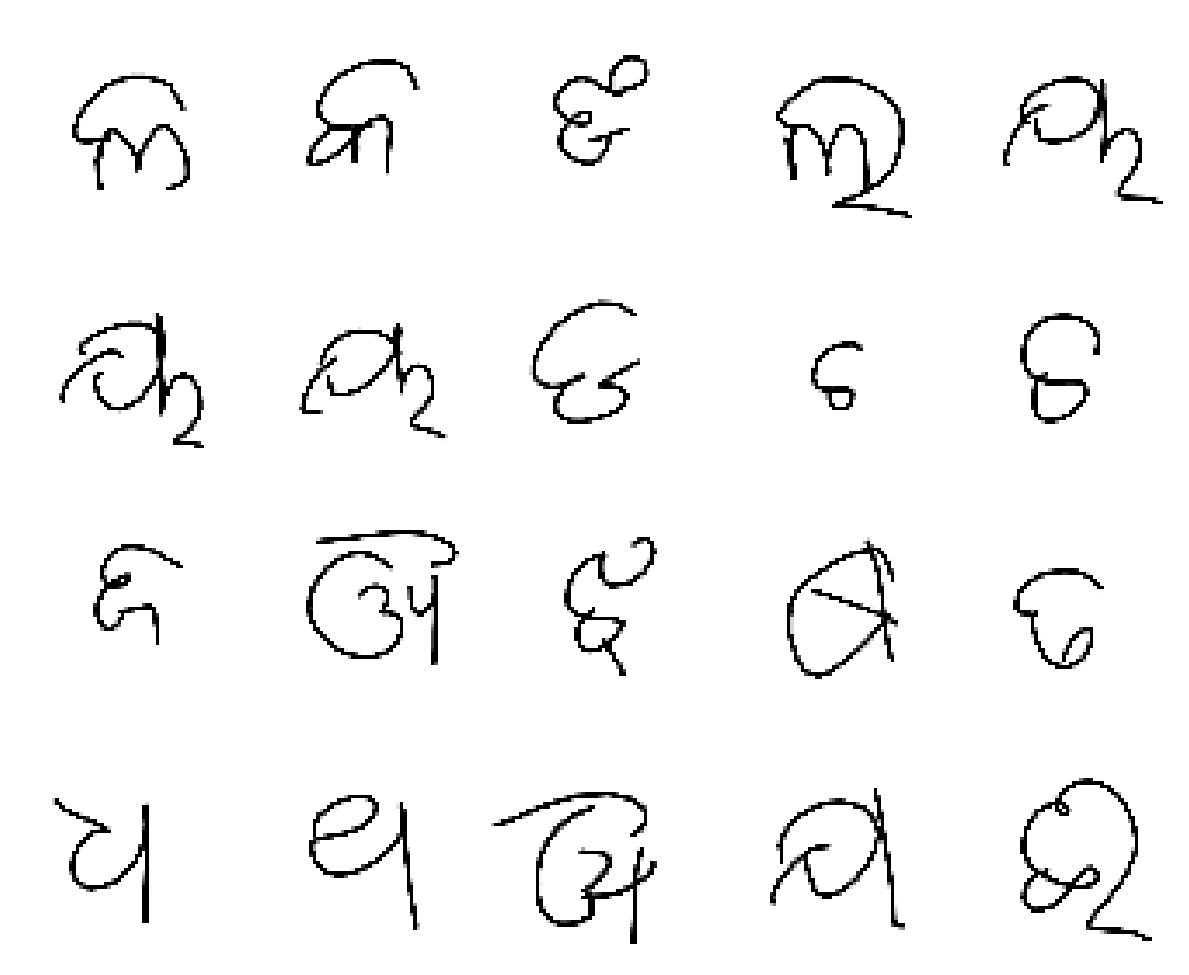

In [ ]:
import random

plt.figure(figsize=(12, 10))

for i in range(20):

    idx = random.randint(0, len(X_train) - 1)

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_train[idx].reshape(64, 64),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Dataset Preparation Complete

At this stage we have successfully:
- mounted Google Drive
- loaded dataset
- encoded labels
- normalized images
- prepared training/testing data

Next step:
Build and train the first CNN model.

Now the actual machine learning begins.
The preprocessing pipeline was the real war.
The neural network arrives later to collect applause.

# Step 13: Build First CNN Model

We now build our first Convolutional Neural Network (CNN).

CNNs are specialized neural networks designed for image processing.

The model will learn:
- edges
- curves
- shapes
- handwriting patterns

This is the first actual OCR learning stage of the project.

Input:
64 × 64 grayscale character image

Output:
predicted Odia character class

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
num_classes = len(valid_classes)

print("Number of Classes:", num_classes)

Number of Classes: 42


## Step 13.1: Implement Data Augmentation

To improve the model's ability to recognize variations in handwritten characters, we'll use **Data Augmentation**. This technique artificially expands the training dataset by applying random transformations to the existing images, such as:

-   **Rotation**: Rotating images by a small angle.
-   **Scaling (Zoom)**: Zooming in or out on images.

This helps the model become more robust to variations in handwriting style, orientation, and size, without needing more physical training data.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configure the ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=10,        # Rotate images by up to 10 degrees
    zoom_range=0.1,           # Zoom in/out by up to 10%
    width_shift_range=0.1,    # Shift images horizontally by up to 10% of total width
    height_shift_range=0.1,   # Shift images vertically by up to 10% of total height
    shear_range=0.1,          # Apply shear transformations
    horizontal_flip=False,    # No horizontal flip for character recognition (can change meaning)
    vertical_flip=False,      # No vertical flip for character recognition (can change meaning)
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Fit the data generator on the training data
datagen.fit(X_train)

print("ImageDataGenerator configured and fitted on training data.")

ImageDataGenerator configured and fitted on training data.


# CNN Architecture

Our CNN contains:

- Convolution layers for feature extraction
- MaxPooling for dimensionality reduction
- Dense layers for classification
- Dropout for overfitting prevention

Architecture:

Input Image
→ Conv Layer
→ Pooling
→ Conv Layer
→ Pooling
→ Flatten
→ Dense
→ Output

In [ ]:
model = Sequential([

    # Input layer
    Input(shape=(64, 64, 1)),

    # First convolution block
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    # Second convolution block
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    # Flatten feature maps
    Flatten(),


    # Dense layer
    Dense(
        128,
        activation='relu'
    ),

    # Regularization
    Dropout(0.3),


    # Output layer
    Dense(
        num_classes,
        activation='softmax'
    )
])

# Step 14: Compile Model

Compiling defines:

- optimizer
- loss function
- evaluation metric

We use:

Optimizer:
Adam

Loss:
categorical_crossentropy

Metric:
accuracy

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 15: Train CNN Model

The model now learns patterns from handwritten Odia characters.

Training Process:
- forward propagation
- loss calculation
- backpropagation
- weight optimization

Epoch:
one complete pass through the dataset

In [ ]:
history = model.fit(

    X_train,
    y_train,

    epochs=1000,

    validation_data=(
        X_test,
        y_test
    )

)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.0347 - loss: 3.7466 - val_accuracy: 0.0593 - val_loss: 3.7014
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1220 - loss: 3.4440 - val_accuracy: 0.2174 - val_loss: 3.1044
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2708 - loss: 2.7021 - val_accuracy: 0.3755 - val_loss: 2.4525
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4137 - loss: 2.1561 - val_accuracy: 0.4704 - val_loss: 2.1387
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5506 - loss: 1.5888 - val_accuracy: 0.4901 - val_loss: 1.9026
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5992 - loss: 1.3583 - val_accuracy: 0.5534 - val_loss: 1.7564
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6815 - loss: 1.0745 - val_accuracy: 0.5850 - val_loss: 1.6362
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7242 - loss: 0.9077 - val_accuracy:

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32), # Use the data generator for training
    epochs=100, # Reduced epochs for demonstration, you can adjust this
    validation_data=(X_test, y_test)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.2619 - loss: 3.0654 - val_accuracy: 0.6917 - val_loss: 1.4966
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3373 - loss: 2.6103 - val_accuracy: 0.7431 - val_loss: 1.2497
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4196 - loss: 2.2219 - val_accuracy: 0.7312 - val_loss: 1.2121
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4514 - loss: 2.0325 - val_accuracy: 0.7352 - val_loss: 1.1722
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4970 - loss: 1.8739 - val_accuracy: 0.7549 - val_loss: 1.1779
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5238 - loss: 1.7398 - val_accuracy: 0.7589 - val_loss: 1.1610
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5327 - loss: 1.6524 - val_accuracy: 0.7826 - val_loss: 1.0092
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5645 - loss: 1.5279 - val_accuracy: 0

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,889,984 (18.65 MB)

 Trainable params: 1,629,994 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,259,990 (12.44 MB)

# Step 16: Save Trained Model

We save the trained OCR model for:
- future predictions
- evaluation
- deployment
- inference testing

In [ ]:
model.save(
    "/content/drive/MyDrive/lipi_models/odia_ocr_cnn.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


# Step 17: Visualize Training Performance

We plot:
- training accuracy
- validation accuracy
- training loss
- validation loss

This helps analyze model behavior.

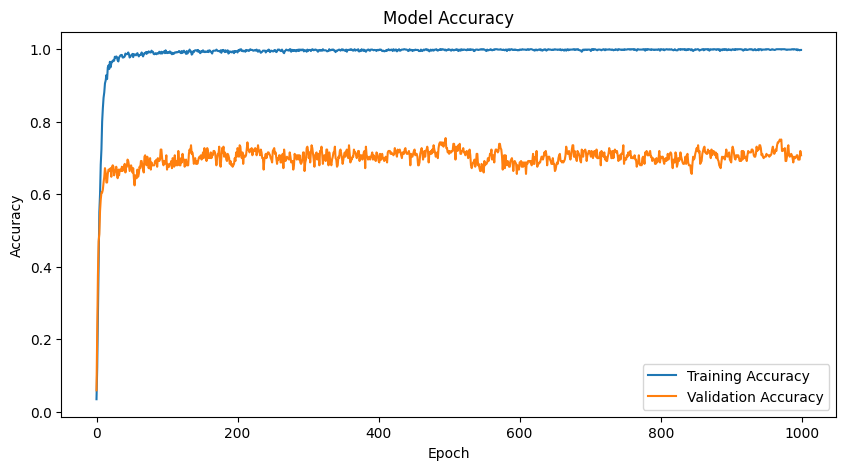

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

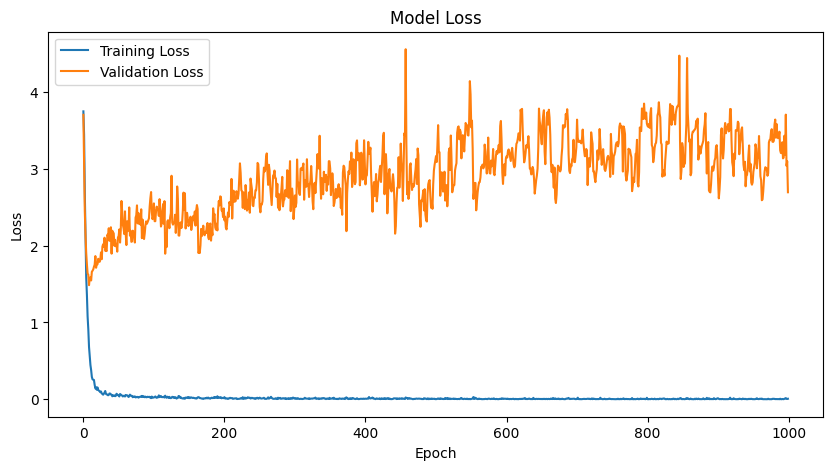

In [ ]:
# Loss Plot
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Step 18: Evaluation Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test)

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Detailed report
print("\nClassification Report")
print(classification_report(y_true, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Accuracy : 0.7075098814229249
Precision: 0.7591626643010043
Recall   : 0.7075098814229249
F1 Score : 0.7125700396078153

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.73      0.73      0.73        11
           2       1.00      0.83      0.91         6
           3       0.60      0.60      0.60         5
           4       0.50      0.50      0.50         4
           5       0.60      0.43      0.50         7
           6       1.00      0.75      0.86         8
           7       0.38      0.83      0.53         6
           8       1.00      0.40      0.57         5
           9       0.71      0.83      0.77         6
          10       0.71      0.62      0.67         8
          11       0.89      1.00      0.94         8
          12       0.50      0.75      0.60         8
          13       1.00      0.82      0.90        11
        

# Step 19: Confusion Matix

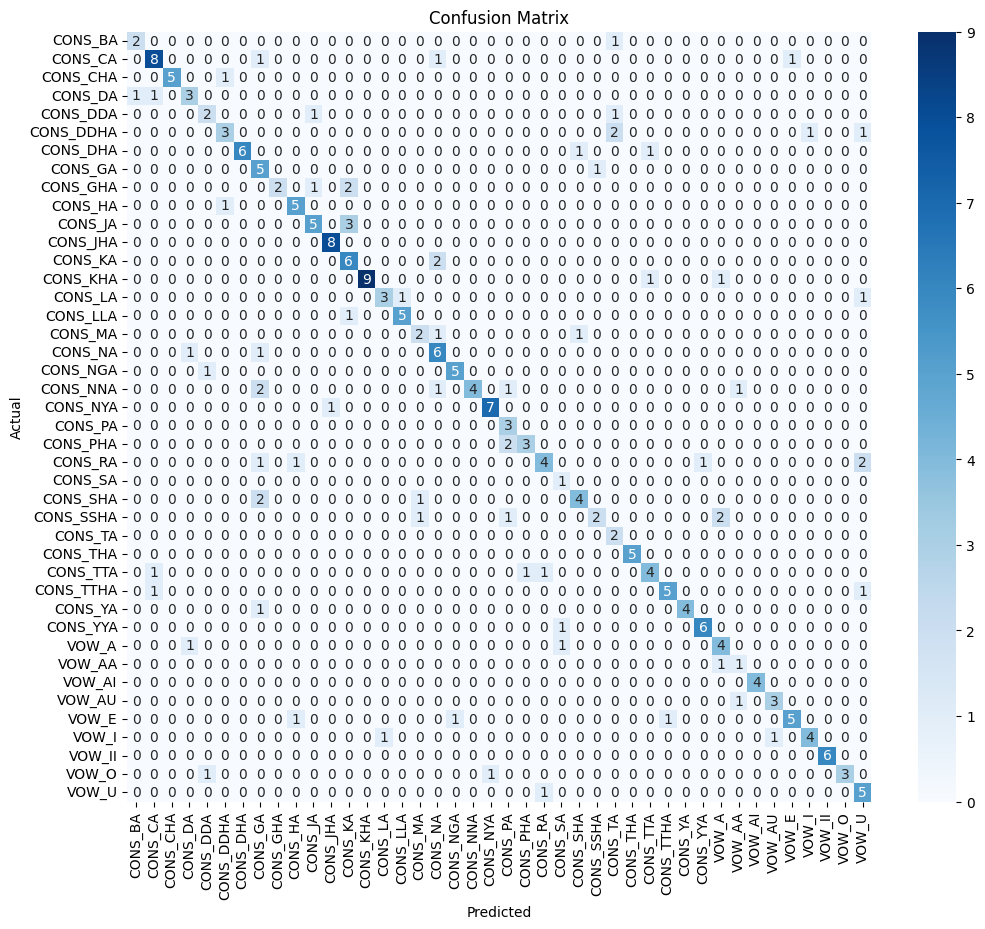

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

class_names = list(label_map.keys())

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Step 20: Test Random Prediction

We now test the OCR model on unseen handwritten images.

The model predicts:
which Odia character the image belongs to.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


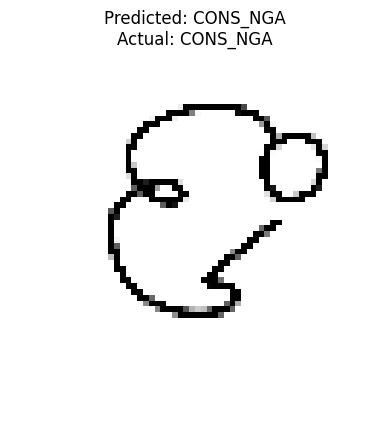

In [ ]:
import random
import numpy as np

# Pick random test image
idx = random.randint(0, len(X_test) - 1)

sample = X_test[idx]

# Predict
prediction = model.predict(
    sample.reshape(1, 64, 64, 1)
)

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_test[idx])

# Reverse label map
reverse_label_map = {
    v: k for k, v in label_map.items()
}

predicted_label = reverse_label_map[predicted_class]

actual_label = reverse_label_map[actual_class]

# Display image
plt.imshow(
    sample.reshape(64, 64),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_label}\nActual: {actual_label}"
)

plt.axis("off")

plt.show()

## Step 21: Conditional Prediction with Augmentation

Here, we implement a strategy where we first attempt to predict on the original image. If the initial prediction is incorrect, we then apply data augmentation to the test image and try to predict again, simulating how augmentation might help in real-world scenarios for difficult samples.


--- Testing Image 144 ---
Actual Label: CONS_JA
Initial Prediction (Original Image): CONS_JA
Result: Correctly predicted without augmentation!


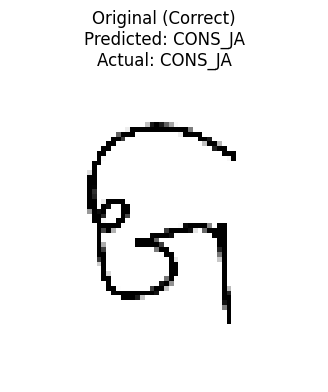

In [ ]:
import random
import numpy as np

# Assuming datagen is already defined and fitted from cell da66b4f5
# If not, please run cell da66b4f5 first.

# Pick a random test image index
idx = random.randint(0, len(X_test) - 1)
sample_image = X_test[idx]
actual_class_idx = np.argmax(y_test[idx])
actual_label = reverse_label_map[actual_class_idx]

print(f"--- Testing Image {idx} ---")
print(f"Actual Label: {actual_label}")

# --- First attempt: Predict on the original image ---

# Reshape for single prediction: (1, height, width, channels)
original_prediction_prob = model.predict(sample_image.reshape(1, 64, 64, 1), verbose=0)
original_predicted_class_idx = np.argmax(original_prediction_prob)
original_predicted_label = reverse_label_map[original_predicted_class_idx]

print(f"Initial Prediction (Original Image): {original_predicted_label}")

if original_predicted_class_idx == actual_class_idx:
    print("Result: Correctly predicted without augmentation!")
    # Display the image and prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.reshape(64, 64), cmap="gray")
    plt.title(f"Original (Correct)\nPredicted: {original_predicted_label}\nActual: {actual_label}")
    plt.axis("off")
    plt.show()

else:
    print("Result: Initial prediction was INCORRECT. Attempting with augmentation...")

    # --- Second attempt: Predict with augmentation ---

    # Generate a batch of augmented images from the single sample
    # Use .flow() to get augmented images. We'll generate 5 augmented versions.
    augmented_images_batch = datagen.flow(
        np.expand_dims(sample_image, axis=0),
        batch_size=1, # Generate one augmented image at a time
        shuffle=False
    )

    augmented_predictions_probs = []
    num_augmentations = 5 # Number of augmented versions to generate

    for _ in range(num_augmentations):
        # Get one augmented image (returns a batch of 1)
        augmented_img_batch, _ = next(augmented_images_batch)
        augmented_img = augmented_img_batch[0] # Extract the single image

        # Predict on the augmented image
        pred_prob = model.predict(augmented_img_batch, verbose=0)
        augmented_predictions_probs.append(pred_prob[0])

    # Convert list of prediction probabilities to numpy array
    augmented_predictions_probs = np.array(augmented_predictions_probs)

    # Aggregate predictions: e.g., by majority vote or averaging probabilities
    # Here, we'll average the probabilities and then take the argmax
    averaged_probs = np.mean(augmented_predictions_probs, axis=0)
    augmented_predicted_class_idx = np.argmax(averaged_probs)
    augmented_predicted_label = reverse_label_map[augmented_predicted_class_idx]

    print(f"Prediction with Augmentation: {augmented_predicted_label}")

    # Display the original image and the outcome
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.reshape(64, 64), cmap="gray")

    if augmented_predicted_class_idx == actual_class_idx:
        plt.title(f"Original (Incorrect, then Corrected by Aug.)\nPredicted: {augmented_predicted_label}\nActual: {actual_label}")
        print("Outcome: Augmentation helped to correctly classify the image!")
    else:
        plt.title(f"Original (Incorrect)\nPredicted: {augmented_predicted_label}\nActual: {actual_label}")
        print("Outcome: Augmentation did NOT help to correctly classify the image.")

    plt.axis("off")
    plt.show()